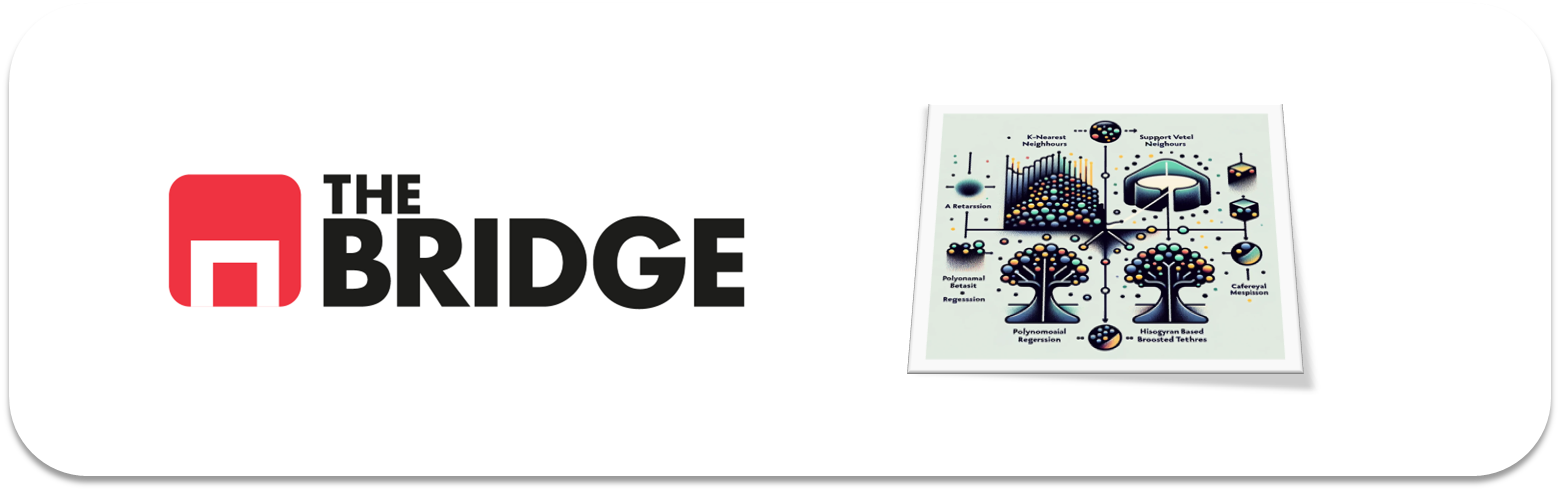

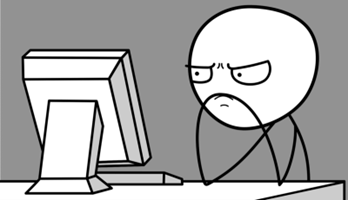

Para hacer un **repaso a los problemas de clasificacion con ML**, completa los siguientes ejercicios. Recuerda que necesitarás datos que están en el directorio data que acompaña al notebook (búscalo en el repositorio de ejercicios)
  
La solución a los mismos las tienes ya, intenta no mirarlos de primeras pero no dejes de hacerlo cuando hayas terminado por si te pudieran aportar.

### INTRODUCCIóN: PROCESO DE ML

En los siguientes ejercicios vamos a seguir (de nuevo) los pasos básicos en la creación de un modelo de ML para resolver un problema de predicción a partir de un dataset que incluye el target, es decir, un aprendizaje supervisado.

En concreto, vamos a trabajar sobre un problema de clasificación a través de los siguientes pasos:

1. Entendimiento del problema (selección de la métrica más adecuada)  
2. Obtención de datos y primer contacto  
3. Train y Test  
4. MiniEDA: Análisis del target, análisis bivariante, entendimiento de las features, selección de las mismas (si es necesario)  
5. Preparación del dataset de Train: Conversión de categóricas, tratamiento de numéricas  
6. Selección e instanciación de modelos. Baseline.
7. Comparación de modelos (lo haremos por comparación con validación, puedes hacerlo por comparación de modelos de hiperparámetros optimizados, si así lo prefieres)  
8. Selección de modelo: Optimización de hiperparámetros (ten en cuenta la nota de 7)  
9. Equilibrado del train set  
10. Evaluación contra test.  
11. Análisis de errores, posibles acciones futuras.  
12. EXTRA: Persistencia del modelo en disco.  

### El problema

La unidad oncológica del hospital de Madison, Wisconsin, está trabajando en un tratamiento muy prometedor sobre el cáncer de mama. Desgraciadamente es un tratamiento con efectos secundarios y todavía excesivamente caro, pero cuya efectividad es extraordinaria si se aplica en las primeras etpas o incluso antes de haberlo desarrollado. 

En este sentido, la univeridad quiere disponer de un modelo que le permita detectar potenciales pacientes pero con un alto nivel de acierto en detectar quien puede tener cáncer para no aplicar el tratamiento a personas que no fueran a desarrollarlo y por tanto no sólo perder dinero, sino también, y más importante causar problemas a esas personas. 

Nos piden trabajar sobre datos que ya tienen, y que pueden obtener facilmente de cualquier futuro aspirante a las pruebas y ensayos con el tratamiento, de pacientes que desarrollaron y no el cáncer. Sobre ese dataset quieren que les proporcionemos el mejor modelo de predicción de quién desarrollará o no el cáncer y que cumpla con las expectativas del párrafo anterior.

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
import bootcampviztools as bt
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, make_scorer, precision_score, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score, train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

### Ejercicio 1: Entendiendo el problema de "Negocio"

En función de la descripción del problema de "negocio" y sin mirar todavía los datos, ¿qué tipo de problema de clasificación vamos a resolver? ¿Qué métricas creess más conveniente para medir el rendimiento del modelo a construir y, por tanto, para comparar posibles modelos entre sí?

*Se trata de un problema de clasificación.*
*La metrica más conveniente sería la precisión ya que el coste de un falso positivo es mayor* 

### Ejercicio 2: Obtención y primer "vistazo"

Carga el dataset, muestra sus primeras filas, su descripción general y determina el tipo de variables que vamos a manejar. Escoge el target y crea una variable `target` y asignalé el nombre de la columna correspondiente.

In [2]:
df = pd.read_csv('./data/wisconsin_cancer.csv', sep='|')
df.head(10)

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374
5,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,0.2087,...,0.03345,0.03672,0.01137,0.02165,0.005082,15.47,23.75,103.40,741.6,0.1791
6,M,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,0.1794,...,0.01382,0.02254,0.01039,0.01369,0.002179,22.88,27.66,153.20,1606.0,0.1442
7,M,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,0.2196,...,0.03029,0.02488,0.01448,0.01486,0.005412,17.06,28.14,110.60,897.0,0.1654
8,M,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,0.2350,...,0.03502,0.03553,0.01226,0.02143,0.003749,15.49,30.73,106.20,739.3,0.1703
9,M,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,0.2030,...,0.07217,0.07743,0.01432,0.01789,0.010080,15.09,40.68,97.65,711.4,0.1853


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   diagnosis               569 non-null    str    
 1   radius_mean             569 non-null    float64
 2   texture_mean            569 non-null    float64
 3   perimeter_mean          569 non-null    float64
 4   area_mean               569 non-null    float64
 5   smoothness_mean         569 non-null    float64
 6   compactness_mean        569 non-null    float64
 7   concavity_mean          569 non-null    float64
 8   concave points_mean     569 non-null    float64
 9   symmetry_mean           569 non-null    float64
 10  fractal_dimension_mean  569 non-null    float64
 11  radius_se               569 non-null    float64
 12  texture_se              569 non-null    float64
 13  perimeter_se            569 non-null    float64
 14  area_se                 569 non-null    float64
 15  

In [4]:
df.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,0.025478,0.031894,0.011796,0.020542,0.003795,16.269190,25.677223,107.261213,880.583128,0.132369
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,0.017908,0.030186,0.006170,0.008266,0.002646,4.833242,6.146258,33.602542,569.356993,0.022832
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,0.002252,0.000000,0.000000,0.007882,0.000895,7.930000,12.020000,50.410000,185.200000,0.071170
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,0.013080,0.015090,0.007638,0.015160,0.002248,13.010000,21.080000,84.110000,515.300000,0.116600
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,0.020450,0.025890,0.010930,0.018730,0.003187,14.970000,25.410000,97.660000,686.500000,0.131300
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,0.032450,0.042050,0.014710,0.023480,0.004558,18.790000,29.720000,125.400000,1084.000000,0.146000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,0.135400,0.396000,0.052790,0.078950,0.029840,36.040000,49.540000,251.200000,4254.000000,0.222600


In [5]:
target = 'diagnosis'

NOTA: Para más información sobre el dataset el hospital nos redirige a esta [página web](https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data?resource=download)

### Ejercicio 3: Split

Haz el split en train y test.

In [6]:
train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)

### Ejercicio 4: MiniEDA (I)

Analiza la distribución frecuencial de target brevemente.

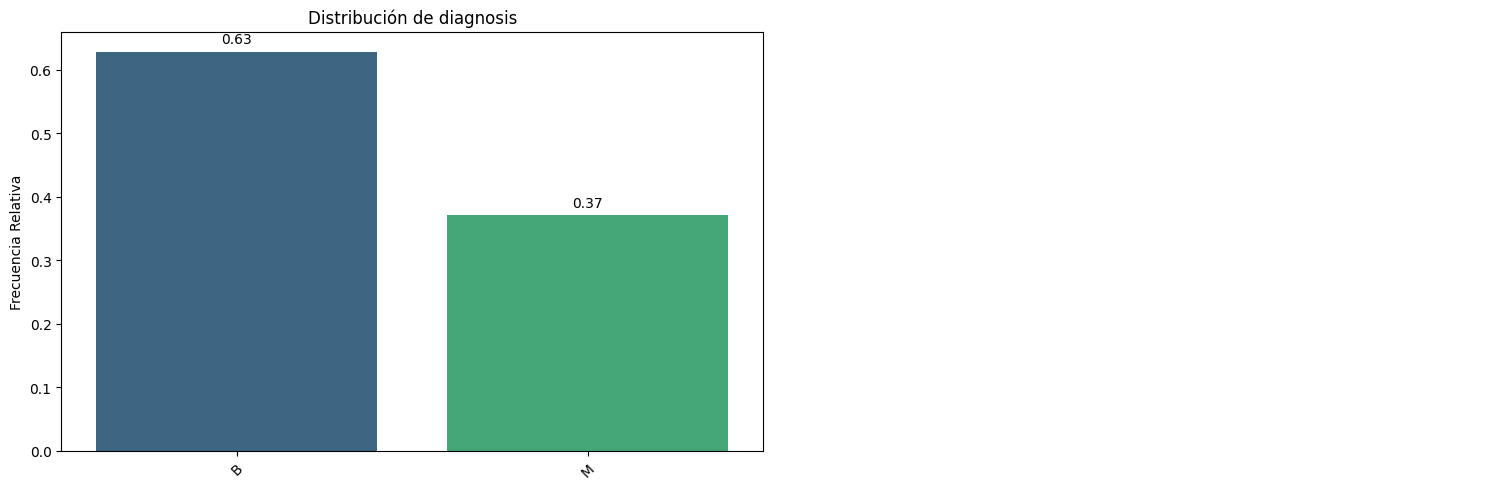

In [7]:
bt.pinta_distribucion_categoricas(train_set, [target], mostrar_valores=True, relativa=True)

*Ligeramente desbalanceado.*


### Ejercicio 5: MiniEDA (II)

Analiza bivariantemente las variables contra el target, de forma que veamos las distintas distribuciones para cada clase (puedes emplear la libería gráfica que crees conveniente)

In [8]:
features_num = train_set.columns.to_list()
features_num.remove(target)
print(len(features_num))

25


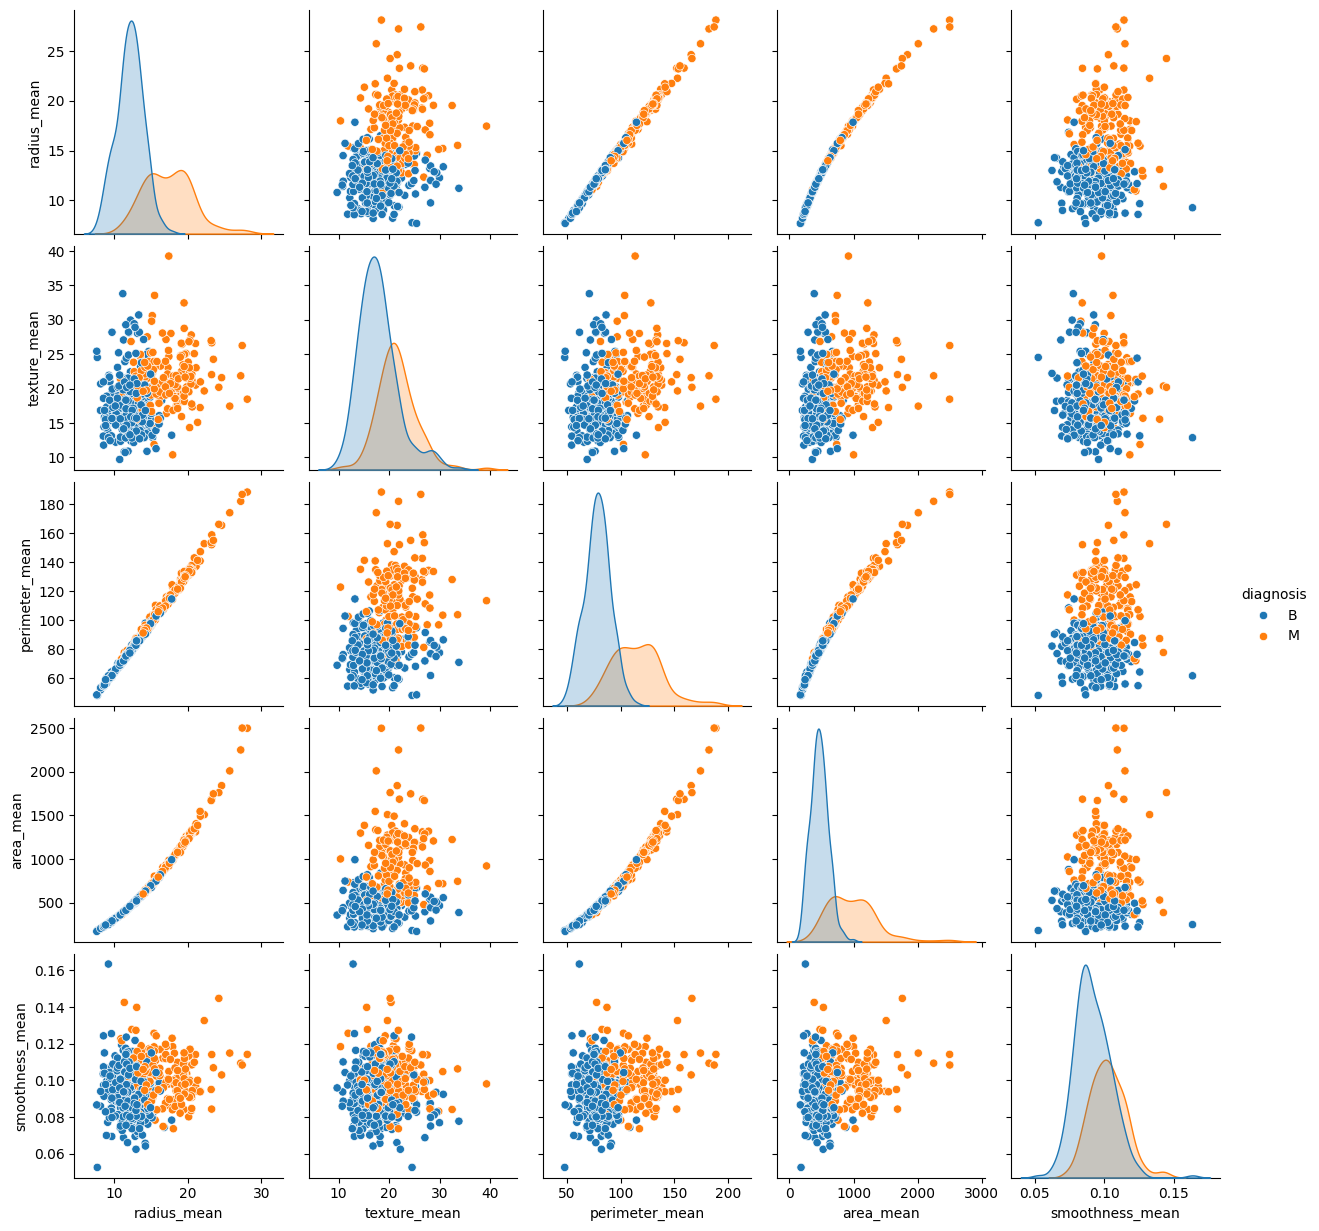

In [9]:
sns.pairplot(train_set[features_num[0:5] + [target]], hue = target)

*Las más interesantes son donde las gráficas sean lo más diferentes, ubicadas en la diagonal. Contra menos se parezca, eso quiere decir que existe una correlación que provoca un cambio significante en la variable target, no reaccionan de la misma manera los dos valores*

*Otro asunto a observar es una posible correlación entre las variables que tengan correlación con la target. Se traduce en problemas de multicolinealidad, por ende, habría que decidir seleccionar una entre todas*

In [10]:
to_investigate_1 = ['area_mean', 'perimeter_mean', 'radius_mean']
# tenerlo en cuenta

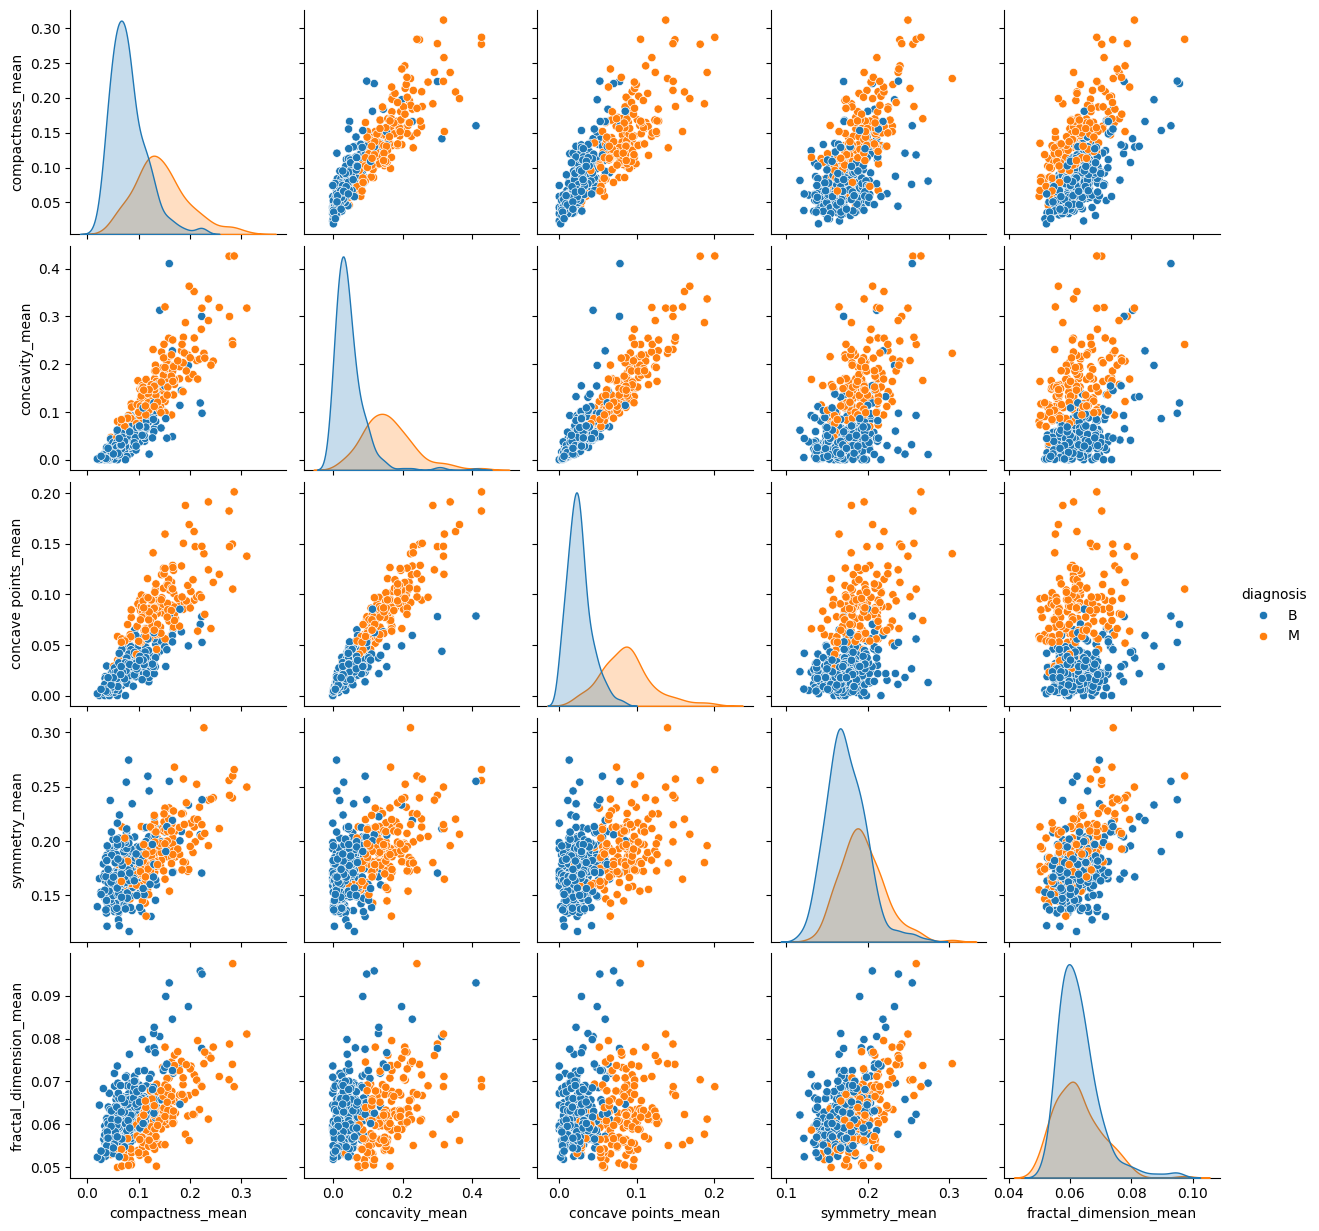

In [11]:
sns.pairplot(train_set[features_num[5:10]+[target]], hue=target)

In [12]:
to_investigate_2 = ['compactness_mean','concavity_mean','concave points_mean']

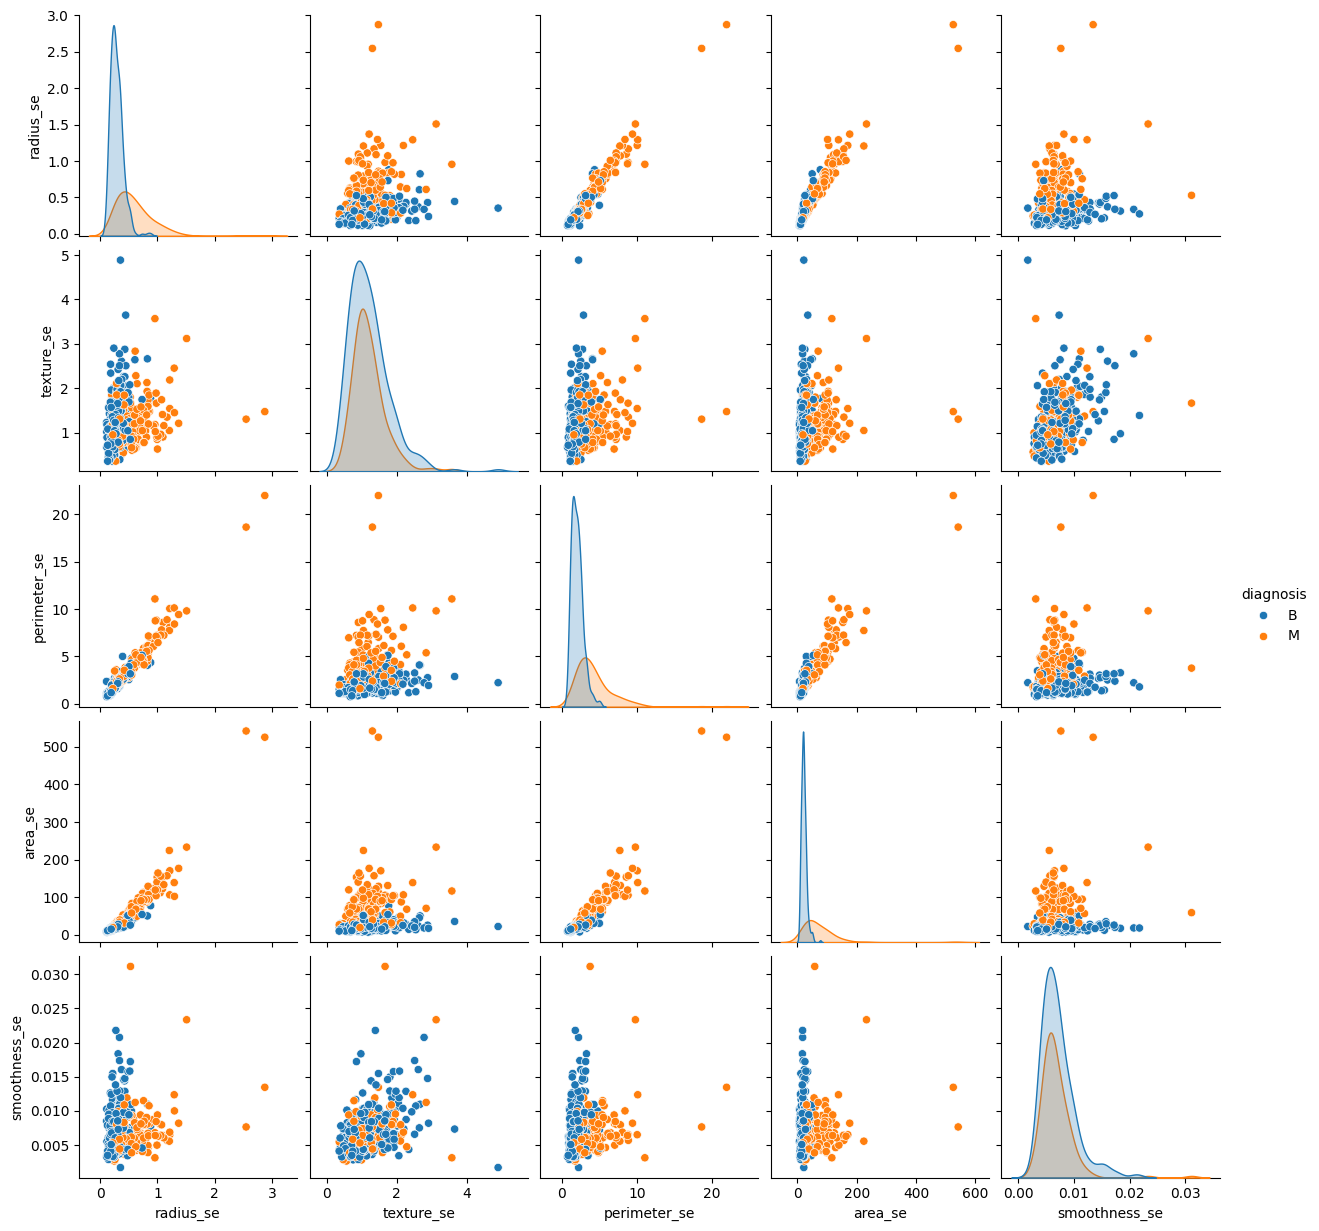

In [13]:
sns.pairplot(train_set[features_num[10:15]+[target]], hue=target)

In [14]:
to_investigate_3 = ['area_se','perimeter_se','radius_se']
features_num_2 = ['smoothnes_se','texture_se']
corr = train_set.corr(numeric_only=True)
corr[to_investigate_1].loc[to_investigate_3]

,area_mean,perimeter_mean,radius_mean
area_se,0.788217,0.729937,0.719478
perimeter_se,0.710713,0.676192,0.656071
radius_se,0.722728,0.680739,0.666954


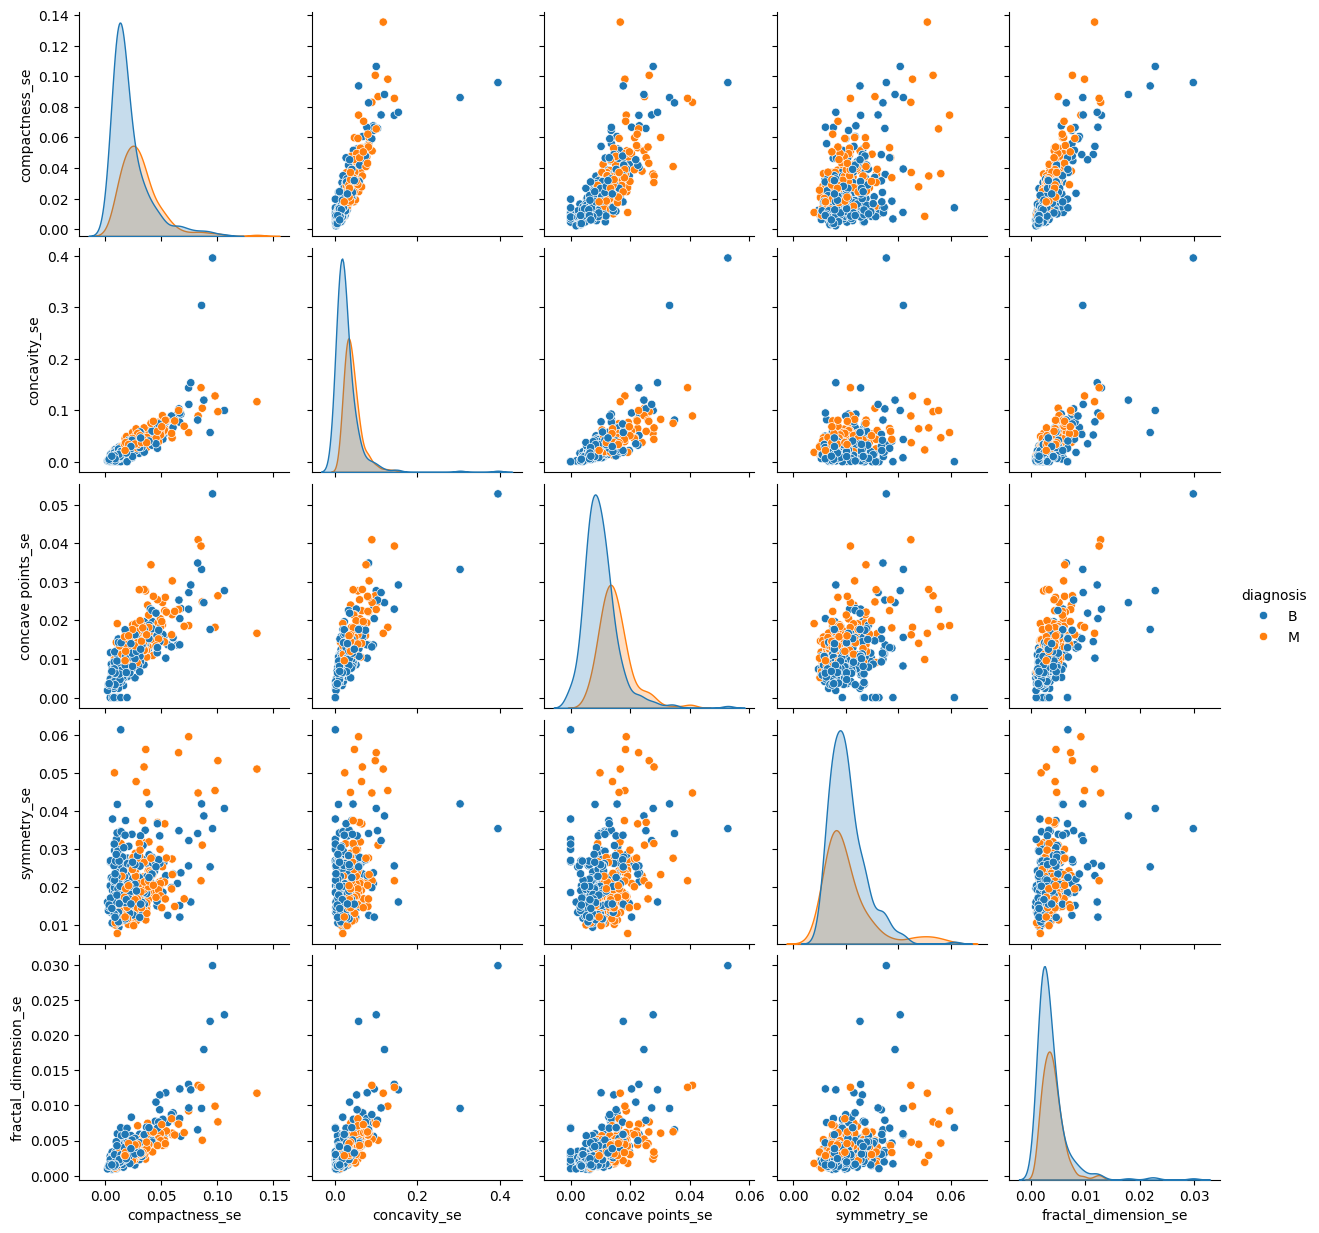

In [15]:
sns.pairplot(train_set[features_num[15:20]+[target]], hue=target);

*Son prácticamente todas aparentemente menos significativas, salco 'fractal_dimension_se' que pasa al segundo dataset*

In [16]:
features_num_2.append('fractal_dimension_se')

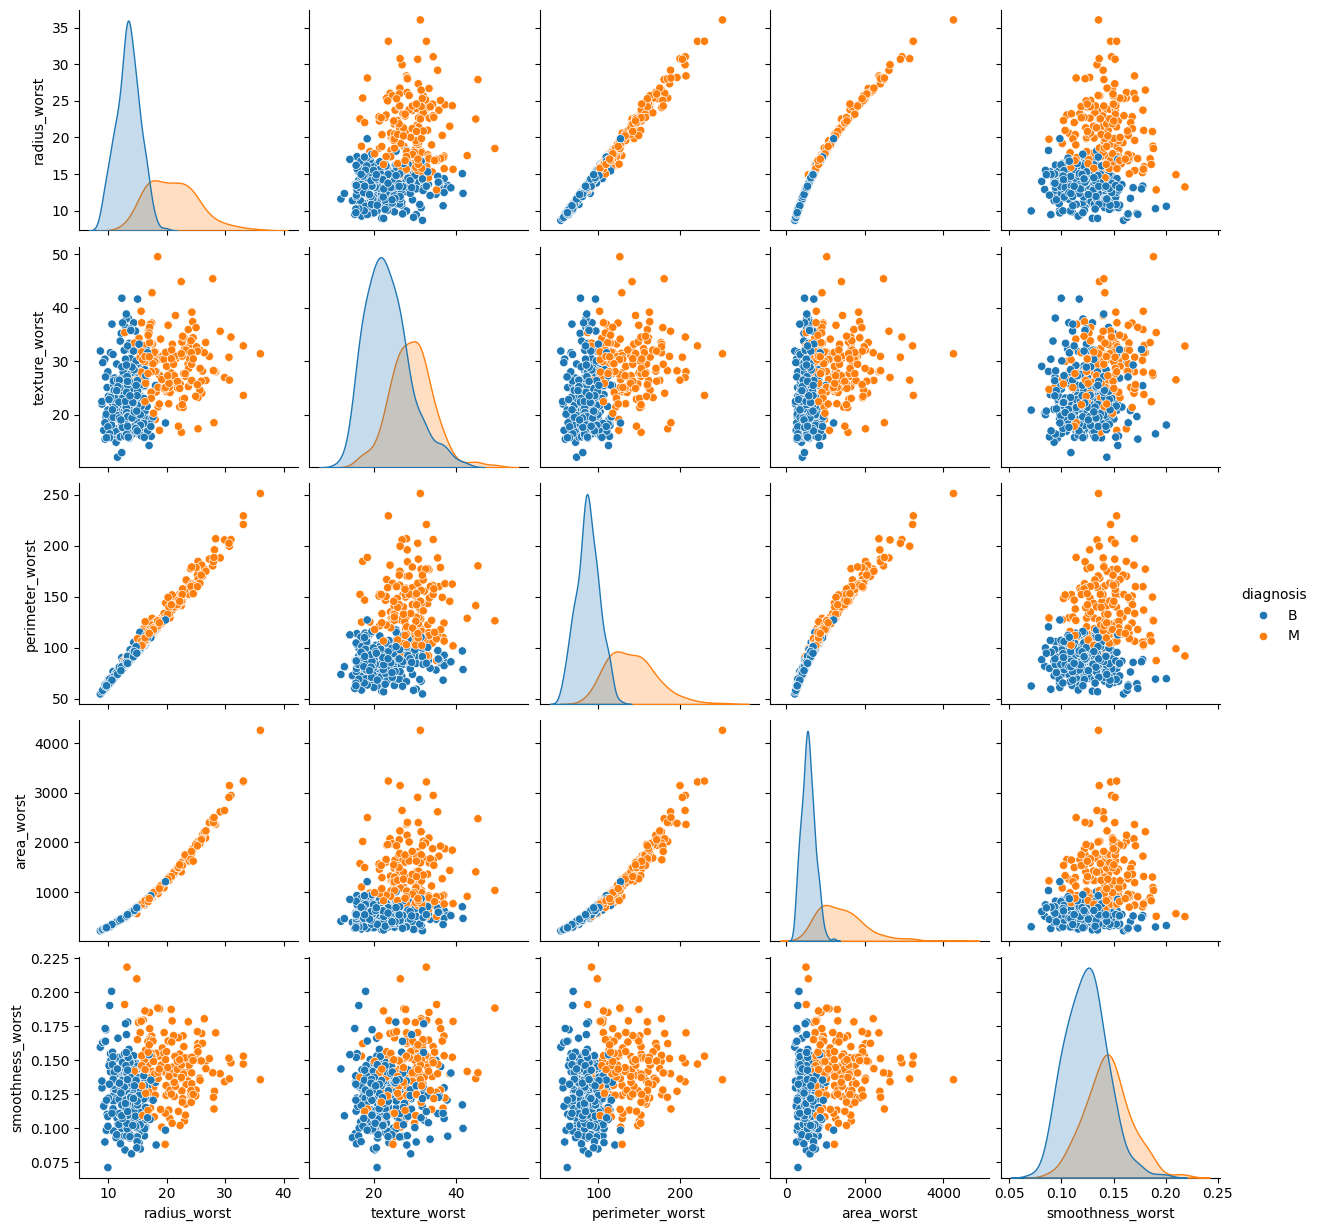

In [17]:
sns.pairplot(train_set[features_num[20:25]+[target]],hue=target)

*Nos llama la atención las que se correlacionan entre sí*

In [18]:
to_investigate_4 = ["radius_worst","perimeter_worst","area_worst"]
corr[to_investigate_1+to_investigate_2+to_investigate_3+to_investigate_4].loc[to_investigate_1+to_investigate_2+to_investigate_3+to_investigate_4]

,area_mean,perimeter_mean,radius_mean,compactness_mean,concavity_mean,concave points_mean,area_se,perimeter_se,radius_se,radius_worst,perimeter_worst,area_worst
area_mean,1.000000,0.985985,0.986609,0.471296,0.659793,0.814273,0.788217,0.710713,0.722728,0.960519,0.955701,0.959723
perimeter_mean,0.985985,1.000000,0.997850,0.529721,0.688251,0.842081,0.729937,0.676192,0.680739,0.969620,0.969674,0.943283
radius_mean,0.986609,0.997850,1.000000,0.477986,0.647311,0.812377,0.719478,0.656071,0.666954,0.969134,0.963536,0.941849
compactness_mean,0.471296,0.529721,0.477986,1.000000,0.877467,0.825932,0.435444,0.534119,0.482867,0.514854,0.573716,0.493183
concavity_mean,0.659793,0.688251,0.647311,0.877467,1.000000,0.914671,0.597401,0.642794,0.615554,0.665091,0.710338,0.659259
concave points_mean,0.814273,0.842081,0.812377,0.825932,0.914671,1.000000,0.675184,0.694657,0.684833,0.827695,0.855666,0.811102
area_se,0.788217,0.729937,0.719478,0.435444,0.597401,0.675184,1.000000,0.937271,0.951025,0.735075,0.740394,0.793332
perimeter_se,0.710713,0.676192,0.656071,0.534119,0.642794,0.694657,0.937271,1.000000,0.973560,0.676239,0.701606,0.712575
radius_se,0.722728,0.680739,0.666954,0.482867,0.615554,0.684833,0.951025,0.973560,1.000000,0.698484,0.704374,0.737451
radius_worst,0.960519,0.969620,0.969134,0.514854,0.665091,0.827695,0.735075,0.676239,0.698484,1.000000,0.993315,0.983458


*Existen correlaciones muy elevadas entre las variables seleccionadas (problema de multicolinealidad)*

### Ejercicio 6: MiniEDA (III)

Crea una variable de tipo lista a la que asignes los valores de las columnas que creas conveniente emplear como features en función de lo visto en el miniEDA. Haz una lista de modelos/algoritmos que vas a emplear para hacer el modelo (solo los nombres). En función de la lista anterior, ¿tienes que tratar las variables, por qué?

In [19]:
features_num_1 = [col for col in features_num if col not in features_num_2] # Todas menos las de "2a" categoria
correladas = to_investigate_1 + to_investigate_2 + to_investigate_3 + to_investigate_4
features_num_0 = [col for col in features_num_1 if col not in correladas]
features_num_0 += ["area_worst","area_se"]

*Emplearemos RandomForest, XGBoost, LightGBM y regresión logística*

### Ejercicio 7: Tratamiento de features

Trata las features de manera que puedan ser empleadas por los modelos que escogite en el ejercicio anterior. Recuerda que este es un paso necesario porque los modelos no entienden de primeras de "letras" (salvo alguno que no es que entienda sino que hace sus transformaciones por dentro) y porque en determinados algoritmos es necesario que los rangos de las features estén escalados para que el algoritmo no se decante (érroneamente) por alguna feature sólo porque sus valores son mayores en rango que el de otras. NOTA: Recuerda que lo que le hagas al train, se lo tienes que hacer al test

*Regresión Logística es sensible al escalado*

*Veamos que features requieren de una transformación a una versión más normal*

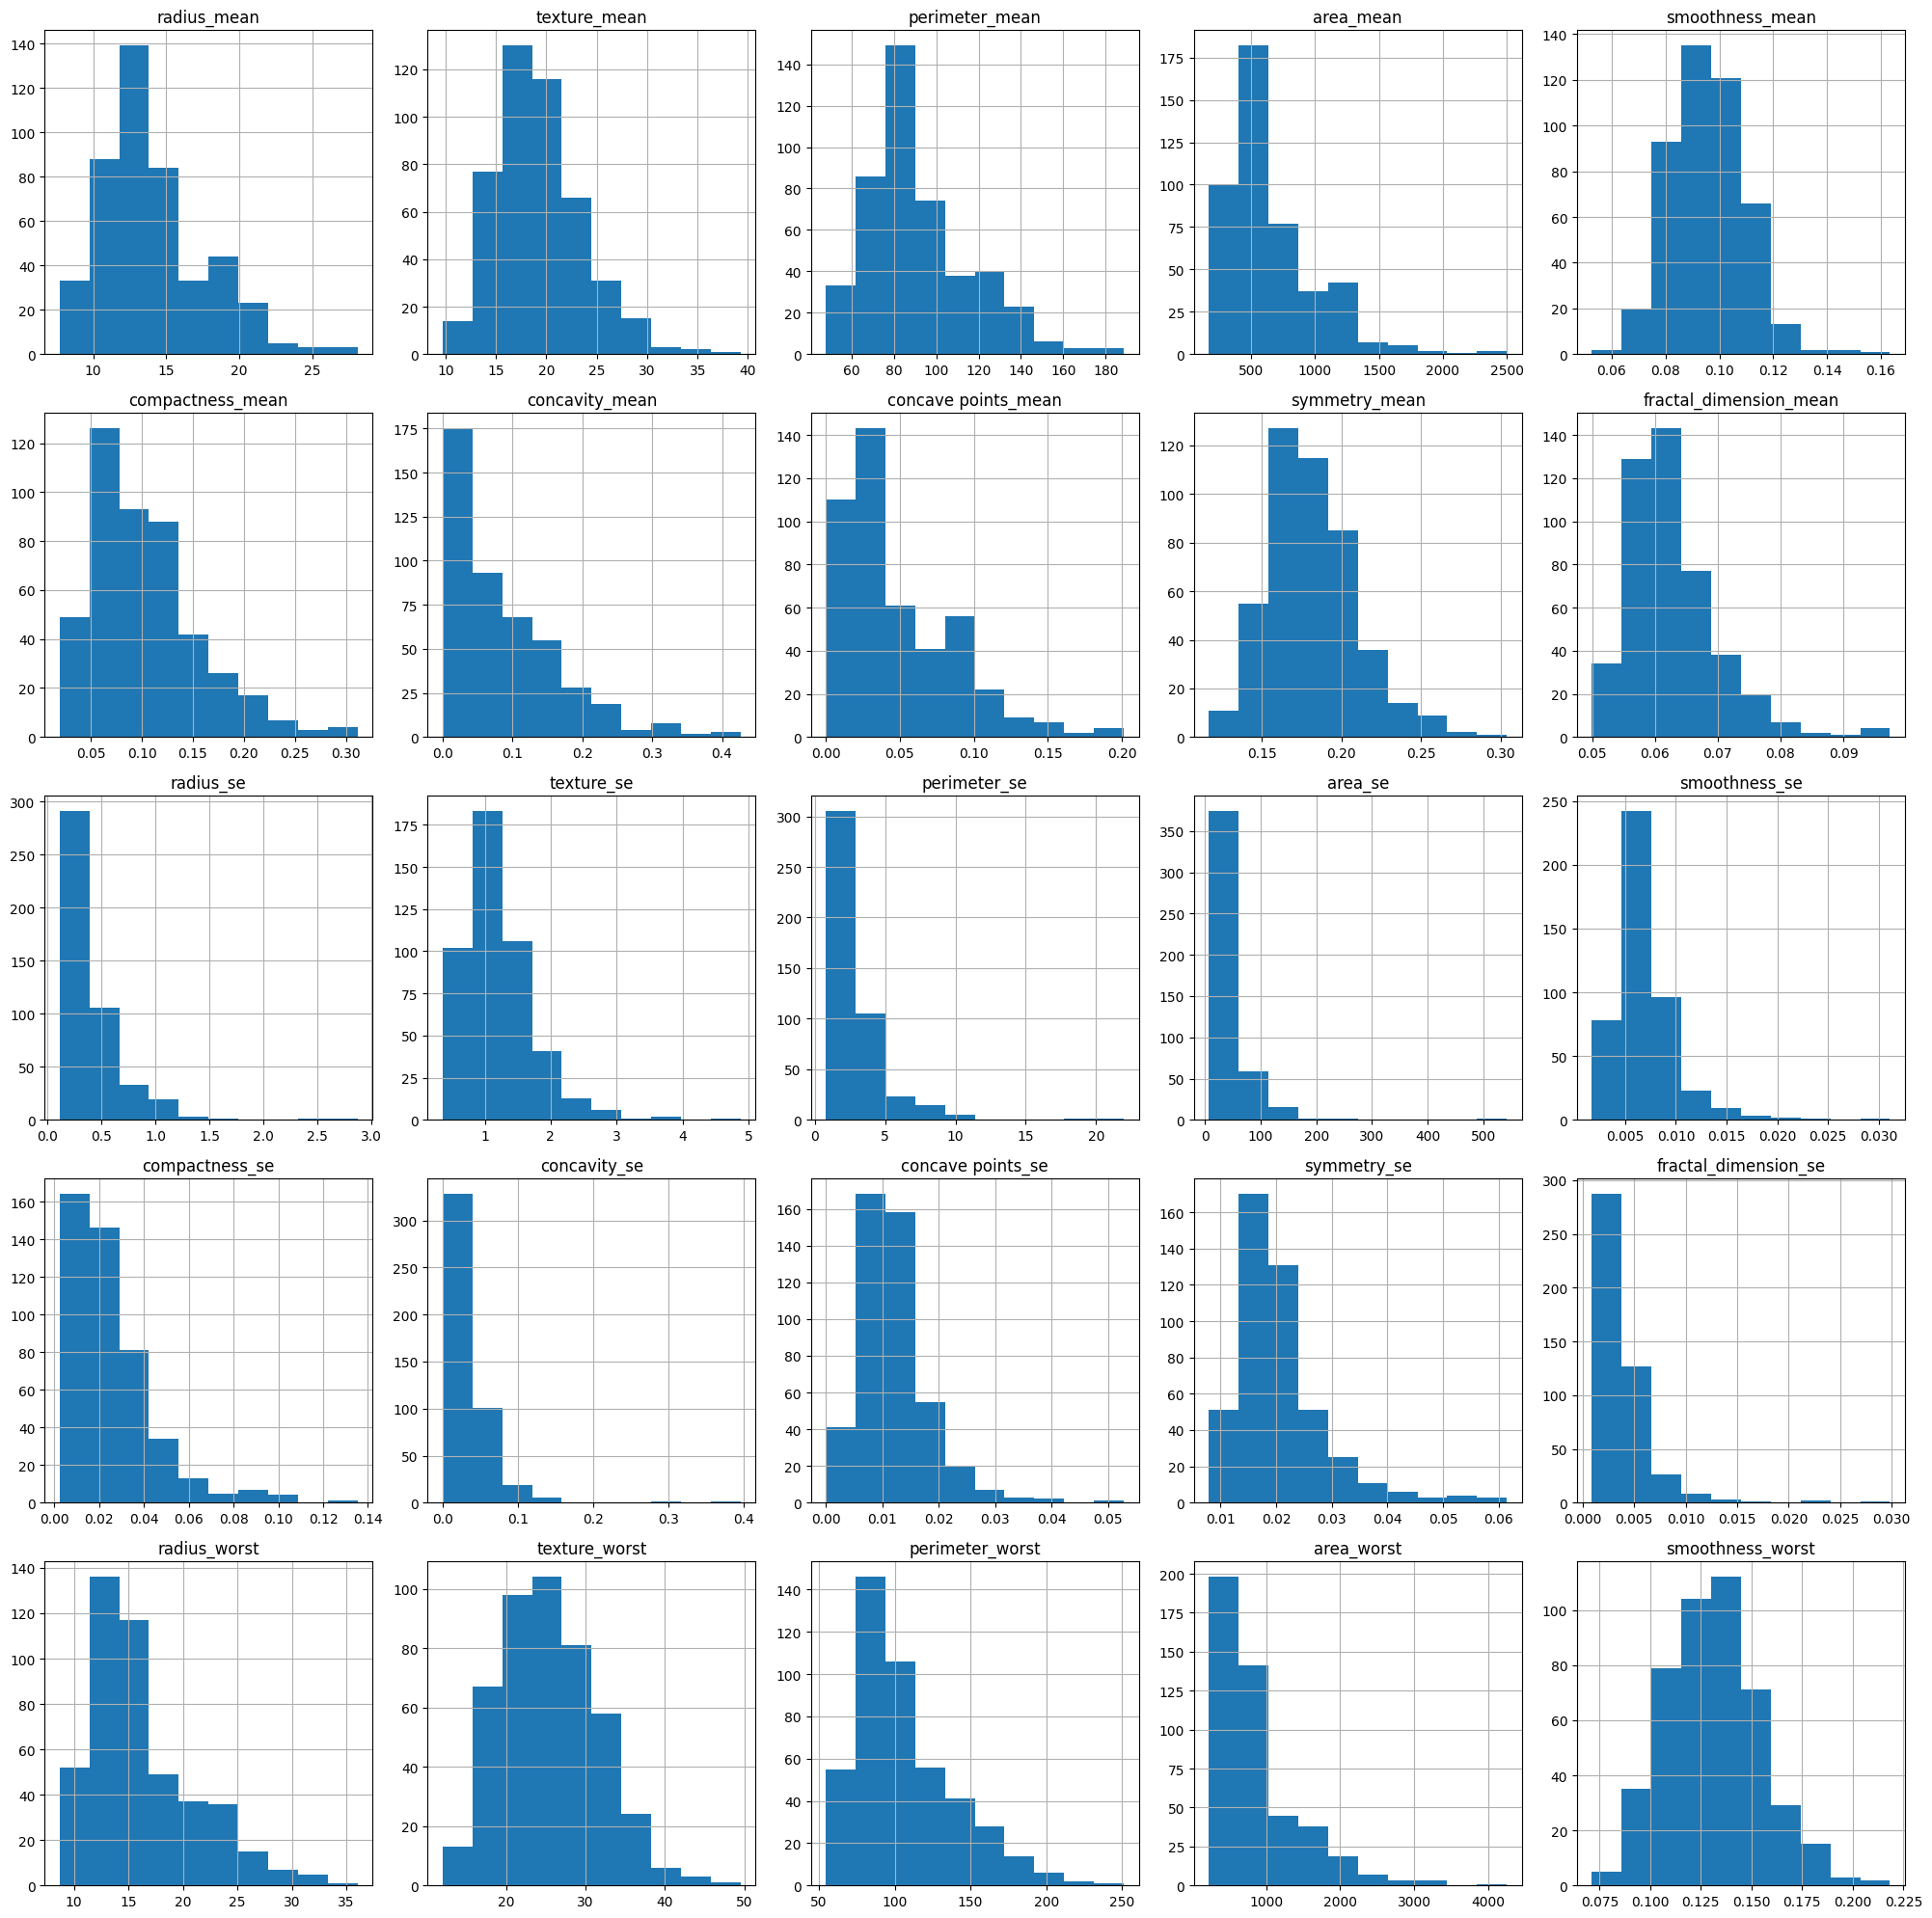

In [20]:
train_set[features_num].hist(figsize=(20,20))
plt.tight_layout()

In [21]:
# Al menos hay que aplicar logaritmo a:
features_to_transform = ['area_mean',
 'compactness_mean',
 'concavity_mean',
 'concave points_mean',
 'radius_se',
 'perimeter_se',
 'area_se',
 'compactness_se',
 'concavity_se',
 'fractal_dimension_se',
 'radius_worst',
 'area_worst']

In [22]:
train_set_scaled = train_set.copy()
test_set_scaled = test_set.copy()

In [23]:
for col in features_to_transform:
    desplaza = 0
    if train_set_scaled[col].min() <= 0:
        desplaza = int(abs(train_set_scaled[col].min())) + 1
    train_set_scaled[col] = np.log(train_set_scaled[col]+desplaza)
    test_set_scaled[col] = np.log(test_set_scaled[col]+desplaza)

In [24]:
scaler = StandardScaler()
train_set_scaled[features_num] = scaler.fit_transform(train_set_scaled[features_num])
test_set_scaled[features_num] = scaler.fit(test_set_scaled[features_num])

### Ejercicio 8: Creación de los dataset de train y test

Crea las parejas X,y de train y test.

In [25]:
y_train = (train_set[target] == "M").astype(int) # Clase 0 -> B, Clase 1 -> M
y_test = (test_set[target] == "M").astype(int) 


X_train_dict = {}
X_test_dict = {}

features_set_name = ["reducido","sin_num_2","todos"]

for set_name,feature_list in zip(features_set_name, [features_num_0,features_num_1,features_num]):
    # Recuerda que features_num ya contiene features_num_2 por eso la usamos al final, para considerar todas las features
    X_train_dict[set_name] = train_set[feature_list]
    X_test_dict[set_name] = test_set[feature_list]

X_train_dict_scaled = {}
X_test_dict_scaled = {}

for set_name,feature_list in zip(features_set_name, [features_num_0,features_num_1,features_num]):
    # Recuerda que features_num ya contiene features_num_2 por eso la usamos al final, para considerar todas las features
    X_train_dict_scaled[set_name] = train_set_scaled[feature_list]
    X_test_dict_scaled[set_name] = test_set_scaled[feature_list]


### Ejercicio 9: Instanciación de modelos

Importa e instancia los modelos que hayas escogido en el ejercicio 6. En general, no hace falta que asignes ahora ningún hiperparámetro salvo en los basados en árboles en los que debes escoger un max_depth para evitar el sobreajuste inicial. Si quieres emplear la regresión logística es posible que tengas que utilizar un valor de max_iter para que el algoritmo converja.

In [26]:
lr_clf = LogisticRegression(max_iter=1000)
rf_clf = RandomForestClassifier(max_depth=6, random_state=42)
lgb_clf = LGBMClassifier(max_depth=6, random_state=42)
xgb_clf = XGBClassifier(max_depht = 6, random_state = 42)

modelos = {
    'Regresion Logistica': lr_clf,
    'Random Forest': rf_clf,
    'Lightgbm': lgb_clf,
    'XGBoost': xgb_clf
}

### Ejercicio 10: Comparativa de modelos

Haz la comparativa de modelos empleando cross_val_score (es decir la validación cruzada). Utiliza k = 5, y un scoring acorde a la métrica escogida en el ejercicio 1. Si no tienes clara la métrica entonces emplea el recall_medio y usa scoring = "balanced acuracy". Escoge el modelo ganador.

In [27]:
# Para scoring precision
scoring_func = make_scorer(precision_score, pos_label = 1)
for feature_set, X_train in X_train_dict.items():
    X_train_scaled = X_train_dict_scaled[feature_set]
    print(f"Para el set {feature_set}:")
    for tipo,modelo in modelos.items():
        print(f"{tipo}: ", end = " ")
        if tipo != "Regresion Logistica":
            print(np.mean(cross_val_score(modelo, X_train, y_train, cv = 5, scoring = scoring_func)))
        else:
            print(np.mean(cross_val_score(modelo, X_train_scaled, y_train, cv = 5, scoring = scoring_func)))
    print("******")

Para el set reducido:
Regresion Logistica:  0.9523147440794499
Random Forest:  0.9568557422969188
Lightgbm:  [LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 136, number of negative: 228
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000646 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1582
[LightGBM] [Info] Number of data points in the train set: 364, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.373626 -> initscore=-0.516691
[LightGBM] [Info] Start training from score -0.516691
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further sp

c:\Users\maxim\AppData\Local\Programs\Python\Python314\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] El sistema no puede encontrar el archivo especificado
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\maxim\AppData\Local\Programs\Python\Python314\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "c:\Users\maxim\AppData\Local\Programs\Python\Python314\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\maxim\AppData\Local\Programs\

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 135, number of negative: 229
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000122 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1582
[LightGBM] [Info] Number of data points in the train set: 364, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.370879 -> initscore=-0.528447
[LightGBM] [Info] Start training from score -0.528447
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

c:\Users\maxim\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:53:53] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "max_depht" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\maxim\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:53:53] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "max_depht" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\maxim\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:53:53] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "max_depht" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\maxim\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:53:53] WARNING: C:\actions-runner\_work\xgboost\

0.9690820683111955
******
Para el set sin_num_2:
Regresion Logistica:  0.9761029411764707
Random Forest:  0.9523952762923351
Lightgbm:  [LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 136, number of negative: 228
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000265 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2798
[LightGBM] [Info] Number of data points in the train set: 364, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.373626 -> initscore=-0.516691
[LightGBM] [Info] Start training from score -0.516691
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

c:\Users\maxim\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:53:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "max_depht" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\maxim\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:53:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "max_depht" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\maxim\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:53:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "max_depht" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\maxim\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:53:54] WARNING: C:\actions-runner\_work\xgboost\

0.9703784695696461
******
Para el set todos:
Regresion Logistica:  0.9766284695696459
Random Forest:  0.9459436633891093
Lightgbm:  [LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 136, number of negative: 228
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000318 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3042
[LightGBM] [Info] Number of data points in the train set: 364, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.373626 -> initscore=-0.516691
[LightGBM] [Info] Start training from score -0.516691
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


c:\Users\maxim\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:53:56] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "max_depht" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\maxim\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:53:56] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "max_depht" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\maxim\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:53:56] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "max_depht" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


0.9649387614283249
******


c:\Users\maxim\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:53:56] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "max_depht" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\maxim\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:53:56] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "max_depht" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [28]:
# Para scoring balanced_accuracy

for feature_set, X_train in X_train_dict.items():
    X_train_scaled = X_train_dict_scaled[feature_set]
    print(f"Para el set {feature_set}:")
    for tipo,modelo in modelos.items():
        print(f"{tipo}: ", end = " ")
        if tipo != "Regresion Logistica":
            print(np.mean(cross_val_score(modelo, X_train, y_train, cv = 5, scoring = "balanced_accuracy")))
        else:
            print(np.mean(cross_val_score(modelo, X_train_scaled, y_train, cv = 5, scoring = "balanced_accuracy")))
    print("******")

Para el set reducido:
Regresion Logistica:  0.944848937760222
Random Forest:  0.9466033237251343
Lightgbm:  [LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 136, number of negative: 228
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000125 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1582
[LightGBM] [Info] Number of data points in the train set: 364, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.373626 -> initscore=-0.516691
[LightGBM] [Info] Start training from score -0.516691
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

c:\Users\maxim\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:56:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "max_depht" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\maxim\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:56:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "max_depht" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\maxim\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:56:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "max_depht" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\maxim\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:56:43] WARNING: C:\actions-runner\_work\xgboost\

0.9559642005622575
******
Para el set sin_num_2:
Regresion Logistica:  0.9606008844719212
Random Forest:  0.9565833956086973
Lightgbm:  [LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 136, number of negative: 228
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000182 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2798
[LightGBM] [Info] Number of data points in the train set: 364, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.373626 -> initscore=-0.516691
[LightGBM] [Info] Start training from score -0.516691
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

c:\Users\maxim\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:56:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "max_depht" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\maxim\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:56:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "max_depht" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\maxim\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:56:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "max_depht" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\maxim\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:56:44] WARNING: C:\actions-runner\_work\xgboost\

0.9647877299740223
******
Para el set todos:
Regresion Logistica:  0.9695135404434007
Random Forest:  0.9429465467097579
Lightgbm:  [LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 136, number of negative: 228
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000211 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3042
[LightGBM] [Info] Number of data points in the train set: 364, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.373626 -> initscore=-0.516691
[LightGBM] [Info] Start training from score -0.516691
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


c:\Users\maxim\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:56:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "max_depht" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\maxim\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:56:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "max_depht" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\maxim\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:56:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "max_depht" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\maxim\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:56:46] WARNING: C:\actions-runner\_work\xgboost\

0.9600921675385218
******


c:\Users\maxim\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:56:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "max_depht" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


*nos quedamos con la regresión logística*

### Ejercicio 11: Ajuste de hiperparámetros

Escoge un grid para ajustar los hiperparámetros de tu modelo. Crea un objeto GridSearch y "ajustalo" (emplea su método fit) para encontrar la mejor combinaciónde hiperparámetros empleando la métrica que decidimos en el ejercio 1. Si no lo tienes claro emplea "balance accuracy". Por otro lado, incluye en el grid, el hiperparámetro que permita que el modelo "compense" el desbalanceo del dataset de entrada, aunque este no lo tenga.

In [29]:
# Para la precision de "M" (clase 1)
param_grid = {
    "C": [0.1, 1,10,100], # 
    "class_weight": ["balanced",None],
    "max_iter": [1000,5000,10000]
}

lr_grid = GridSearchCV(lr_clf,
                       param_grid= param_grid,
                       cv = 5,
                       scoring = scoring_func)

lr_grid.fit(X_train_dict_scaled[features_set_name[-1]], y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...max_iter=1000)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'class_weight': ['balanced', None], 'max_iter': [1000, 5000, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","make_scorer(p..., pos_label=1)"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candi

In [30]:
print(lr_grid.best_params_)

{'C': 0.1, 'class_weight': None, 'max_iter': 1000}


In [31]:
print(lr_grid.best_score_)

0.9819964349376115


In [32]:
# Para "balanced_accuracy"
param_grid = {
    "C": [0.1, 1,10,100], # 
    "class_weight": ["balanced",None],
    "max_iter": [1000,5000,10000]
}

lr2_grid = GridSearchCV(lr_clf,
                       param_grid= param_grid,
                       cv = 5,
                       scoring = "balanced_accuracy")

lr2_grid.fit(X_train_dict_scaled[features_set_name[-1]], y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...max_iter=1000)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'class_weight': ['balanced', None], 'max_iter': [1000, 5000, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displ

In [33]:
print(lr2_grid.best_params_)

{'C': 1, 'class_weight': None, 'max_iter': 1000}


In [34]:
print(lr2_grid.best_score_)

0.9695135404434007


### Ejercicio 12: Evaluación del modelo

Evalúa el modelo contra el dataset de test. Muestra el informe de clasificación y haz una valoración de si el hospital aceptaría el modelo o no.

In [35]:
y_pred = lr_grid.best_estimator_.predict(X_test_dict_scaled[features_set_name[-1]])
print(classification_report(y_test, y_pred))

TypeError: float() argument must be a string or a real number, not 'StandardScaler'

In [36]:
y_pred_2 = lr2_grid.best_estimator_.predict(X_test_dict_scaled[features_set_name[-1]])
print(classification_report(y_test, y_pred))

TypeError: float() argument must be a string or a real number, not 'StandardScaler'

### Ejercicio 13: Análisis de errores

Muestra la matriz de confusión con los porcentajes de precisión (emplea ConfusionMatrixDisplay.from_predictions con el argumento normalize con el valor adecuado). Haz un pequeño análisis.

In [37]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, normalize= "pred")

NameError: name 'y_pred' is not defined

### EXTRA: 

Busca en Internet o pregúntale a tu AI preferida, cómo se graba un modelo en disco y gúardalo en "./models/cancer_pred" con la extesión apropiada.